# Optimización day-ahead de costos en microrred conectada a la red considerando emisiones
**EMS, MILP, UC+ED, scheduling**  

Scheduling óptimo con Pyomo. Función objetivo ponderada (suma escalar) barriendo λ ∈ [0, 1] en 11 puntos.

V1: Versión en PYOMO basado en [https://gurobipy-pandas.readthedocs.io/en/stable/examples/unit-commitment.html](https://gurobipy-pandas.readthedocs.io/en/stable/examples/unit-commitment.html) y en el Ejemplo 12.15 del libro [Model Building in Mathematical Programming](https://share.google/ovWcmGq54LiyOcWm8) de H. Paul Williams (5ª edición, págs. 270-271 y 325-326).

Formulación MILP con:
- Satisfacción exacta de la demanda por período
- Restricción de reserva operativa (15% sobre la demanda neta)
- Costos fijos por generador activo, costos marginales y costos de arranque
- Objetivo: minimizar costo total de operación

V2: El problema de Williams de despacho nacional (≈ 45 GW) redimensionado a escala de microrred (≈ 2.1 MW pico). Se reeplazaron los generadores térmicos por generadores diesel.

V3: Se pasa de una representación agregada de la demanda en 5 bloques horarios a una discretización horaria completa (24 períodos).

V4: Se agregan restricciones de rampa (ramp-up y ramp-down) para limitar la tasa de cambio de producción entre períodos consecutivos. Las restricciones se formulan de manera trivialmente satisfecha (ramp_limit = Pmax) dado que los generadores diesel tienen una dinámica de carga mucho más rápida que el paso de tiempo de 1 hora.

V5: Se incorpora un generador fotovoltaico (GFV). Los datos de irradiancia y temperatura corresponden al parque solar de la UTN FR Santa Fe, día 01/01/2019 (promedios horarios).

V6: Conexión a la red de servicio (grid-tied operation). La microrred puede importar energía del mercado (`p_buy[t]`) o exportar excedentes (`p_sell[t]`). Se agrega una variable binaria `is_buying[t]` para garantizar que importación y exportación sean mutuamente excluyentes en cada período. Los precios horarios de compra/venta se basan en el perfil dinámico de Nemati et al. (BDEW, mercado alemán), escalado a $/kWh.

V7: **Análisis biobjetivo Costo–Emisiones CO₂.** Se incorpora el costo de externalidad del CO₂ producido por los generadores diesel y por la energía importada de la red. Se genera un **frente de Pareto** resolviendo 11 instancias MILP con λ ∈ {0.0, 0.1, …, 1.0}:

$$\min \quad \lambda \cdot C^{\mathrm{op}} + (1-\lambda) \cdot C^{\mathrm{em}}$$

Los datos de factores de emisión y costos de externalidad provienen de la Tabla 2.2 de Nemati et al. (2017).

## Problema: Trade-off Costo Operativo vs. Emisiones CO₂

### Función objetivo ponderada

Se combinan linealmente los dos objetivos mediante el parámetro de ponderación λ ∈ [0, 1]:

$$\min \; \lambda \cdot C^{\mathrm{op}} + (1-\lambda) \cdot C^{\mathrm{em}}$$

donde:

$$C^{\mathrm{op}} = \sum_{g,t}\bigl[c_g n_{g,t} + \sigma_{g,t} + s^u_g u_{g,t} + s^d_g v_{g,t}\bigr] + \sum_t \bigl[\pi^{\mathrm{buy}}_t p^{\mathrm{buy}}_t - \pi^{\mathrm{sell}}_t p^{\mathrm{sell}}_t\bigr]$$

$$C^{\mathrm{em}} = \alpha_{\mathrm{CO_2}} \cdot \Biggl[ \underbrace{\beta_{\mathrm{DG}} \sum_{g,t} x_{g,t}}_{\text{diesel}} + \underbrace{\beta_{\mathrm{grid}} \sum_t p^{\mathrm{buy}}_t}_{\text{red importada}} \Biggr]$$

Ambos objetivos están expresados en **\$**, lo que permite la suma directa sin factor de escala adicional. El FV no tiene emisiones.

### Parámetros de emisiones (Nemati et al., Tabla 2.2)

| Fuente | Factor de emisión β | Costo externalidad α | Unidad |
|:---|---:|---:|:---|
| Generadores diesel (DG) | 649,5 | 0,0275 | g CO₂/kWh — \$/kg |
| Red eléctrica (main grid) | 889,1 | 0,0275 | g CO₂/kWh — \$/kg |
| Solar FV | 0 | — | — |

> **Observación clave:** β_grid (889 g/kWh) > β_diesel (649 g/kWh). Esto refleja el mix eléctrico alemán de 2017, con alta participación de carbón. Como consecuencia, **minimizar emisiones implica reducir la importación de red y aumentar la generación diesel propia** — un trade-off no intuitivo pero físicamente correcto para ese contexto. En el frente de Pareto se verá que moverse desde λ=1 (solo costo) hacia λ=0 (solo emisiones) aumenta el costo operativo a la vez que reduce las emisiones.

### Notas sobre la configuración V7

- Todos los datos, parámetros y restricciones son idénticos a V6.
- Se agrega una **función `build_and_solve(lam)`** que construye el modelo completo y lo resuelve para un valor dado de λ. Se llama 11 veces en el barrido del frente de Pareto.
- La función objetivo es la suma escalar ponderada; el resto del modelo (balance, reserva, MUT/MDT, rampa, Big-M PCC) permanece sin cambios.
- El frente de Pareto se grafica con los objetivos en sus unidades naturales: **C_op [\$]** en el eje X y **C_em [kg CO₂]** en el eje Y (sin monetizar), siguiendo el estilo de Nemati Fig. 5.9.
- También se muestra la versión monetizada (ambos en \$) para facilitar la comparación de magnitudes.

## Importaciones y configuración

In [104]:
import pyomo.environ as pe
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import time
import os

## Creación de Archivos de Datos

Idénticos a V6. Se sobreescriben si ya existen.

In [105]:
os.makedirs("data", exist_ok=True)

gen_lines = [
    "generator_class,num_available,min_output,max_output,cost_per_hour,startup_cost,shutdown_cost,min_up_time,min_down_time,ramp_limit,state0",
    "diesel_small,12,20.0,40.0,2.5,5.0,2.5,1,1,40.0,0",
    "diesel_med,10,50.0,100.0,5.8,12.0,6.0,1,1,100.0,0",
    "diesel_large,5,125.0,250.0,14.5,25.0,12.5,1,1,250.0,0",
]
with open("data/generators_diesel.csv", "w") as f:
    f.write("\n".join(gen_lines) + "\n")

solar_lines = ["hora,irradiancia,temperatura",
    "0,0.0,27.9","1,0.0,27.55","2,0.0,27.17","3,0.0,26.81",
    "4,0.0,26.48","5,0.0,26.13","6,16.0,26.36","7,89.16,27.53",
    "8,335.67,29.08","9,540.83,32.1","10,679.33,32.4","11,990.67,33.98",
    "12,773.17,35.03","13,739.0,34.73","14,196.5,30.81","15,747.17,32.45",
    "16,668.67,33.65","17,402.33,32.86","18,88.67,31.15","19,51.17,29.46",
    "20,5.17,26.98","21,0.0,28.15","22,0.0,28.67","23,0.0,28.5"]
with open("data/solar_utn_santafe.csv", "w") as f:
    f.write("\n".join(solar_lines) + "\n")

price_profile = {
    **{h: (0.08, 0.04) for h in range(0, 7)},
    **{h: (0.22, 0.06) for h in range(7, 12)},
    **{h: (0.15, 0.05) for h in range(12, 18)},
    **{h: (0.48, 0.06) for h in range(18, 23)},
    23: (0.10, 0.04),
}
market_lines = ["hora,price_buy,price_sell"] + [f"{h},{b},{s}" for h,(b,s) in price_profile.items()]
with open("data/market_prices.csv", "w") as f:
    f.write("\n".join(market_lines) + "\n")

demand_hourly = [
    820, 790, 810, 800, 830, 870,
   1050,1380,1575,1420,1350,1380,
   1520,1480,1400,1620,1850,2050,
   2100,1980,1750,1550,1350,1100,
]
import datetime
base = datetime.datetime(2024, 1, 1)
tp_lines = ["time_period,expected_demand"] + [
    f"{base + datetime.timedelta(hours=h)},{d}" for h,d in enumerate(demand_hourly)]
with open("data/time_periods.csv", "w") as f:
    f.write("\n".join(tp_lines) + "\n")

print("Archivos CSV creados: generators_diesel, solar_utn_santafe, market_prices, time_periods")


Archivos CSV creados: generators_diesel, solar_utn_santafe, market_prices, time_periods


## Modelo FV (Loyarte) y Carga de Datos

In [106]:
PV_N=1000; PV_Ppico=400; PV_kp=-0.0045; PV_Tr=25.0; PV_Gstd=1000.0; PV_eta=0.92

def loyarte_pv(G, T_amb):
    if G <= 0: return 0.0
    Tc = T_amb + 0.031*G
    return max(PV_N*(G/PV_Gstd)*PV_Ppico*(1+PV_kp*(Tc-PV_Tr))*PV_eta*1e-3, 0.0)

generator_data   = pd.read_csv('data/generators_diesel.csv', index_col='generator_class')
time_period_data = pd.read_csv('data/time_periods.csv', parse_dates=['time_period'], index_col='time_period')
market_data      = pd.read_csv('data/market_prices.csv', index_col='hora')
solar_data       = pd.read_csv('data/solar_utn_santafe.csv', index_col='hora')

GENERATORS   = list(generator_data.index)
TIME_PERIODS = list(time_period_data.index)
T            = list(range(len(TIME_PERIODS)))

pv_profile = {h: round(loyarte_pv(solar_data.loc[h,'irradiancia'],
                                    solar_data.loc[h,'temperatura']), 2) for h in range(24)}

num_available = generator_data['num_available'].to_dict()
min_output    = generator_data['min_output'].to_dict()
max_output    = generator_data['max_output'].to_dict()
cost_per_hour = generator_data['cost_per_hour'].to_dict()
startup_cost  = generator_data['startup_cost'].to_dict()
shutdown_cost = generator_data['shutdown_cost'].to_dict()
min_up_time   = generator_data['min_up_time'].to_dict()
min_down_time = generator_data['min_down_time'].to_dict()
ramp_limit    = generator_data['ramp_limit'].to_dict()
state0        = generator_data['state0'].to_dict()

expected_demand  = {i: time_period_data['expected_demand'].iloc[i] for i in T}
pv_output        = {i: pv_profile[i] for i in T}
price_buy        = {i: market_data.loc[i,'price_buy']  for i in T}
price_sell       = {i: market_data.loc[i,'price_sell'] for i in T}
minimum_active_capacity = {i: round(expected_demand[i]*1.15, 2) for i in T}

PCC_LIMIT = 500.0
BIG_M     = PCC_LIMIT

print(f'Generadores: {GENERATORS}')
print(f'Periodos: {len(T)}  |  FV pico: {max(pv_profile.values()):.1f} kW  |  FV diario: {sum(pv_profile.values()):.1f} kWh')


Generadores: ['diesel_small', 'diesel_med', 'diesel_large']
Periodos: 24  |  FV pico: 299.4 kW  |  FV diario: 2026.5 kWh


## Linealización de Costos de Combustible (Parisio)

In [107]:
quad_params = {
    'diesel_small': {'a': 0.003,  'b': 0.18},
    'diesel_med':   {'a': 0.0012, 'b': 0.20},
    'diesel_large': {'a': 0.0004, 'b': 0.22},
}
N_SEG = 3
lin_segments = {}
for g in GENERATORS:
    a, b = quad_params[g]['a'], quad_params[g]['b']
    support = np.linspace(min_output[g], max_output[g], N_SEG)
    lin_segments[g] = {
        'slopes':     [2*a*pj+b   for pj in support],
        'intercepts': [-a*pj**2   for pj in support],
        'support': support
    }
SEGMENTS = list(range(N_SEG))
print('Segmentos de linealizacion calculados para:', GENERATORS)


Segmentos de linealizacion calculados para: ['diesel_small', 'diesel_med', 'diesel_large']


## Parámetros de Emisiones CO₂
### Fuente: Nemati et al. (2017), Tabla 2.2

Los factores de emisión corresponden al CO₂ equivalente por kWh generado. El costo de externalidad α convierte kg de CO₂ a \$, haciendo que C_em sea directamente comparable con C_op en la función objetivo ponderada.

$$C^{\mathrm{em}} = \alpha_{\mathrm{CO_2}} \cdot \left[ \beta_{\mathrm{DG}} \sum_{g,t} x_{g,t} + \beta_{\mathrm{grid}} \sum_t p^{\mathrm{buy}}_t \right] \quad [\$]$$

La red (mix alemán 2017) tiene un factor de emisión **mayor** que el diesel: importar energía barata de la red es económicamente conveniente (V6) pero ambientalmente perjudicial respecto a generar con diesel propio.

In [108]:
# ── Parámetros de emisiones CO2 (Nemati et al. 2017, Tabla 2.2) ──────────────
ALPHA_CO2   = 0.0275   # $/kg  — costo de externalidad del CO2
BETA_DIESEL = 0.6495   # kg CO2/kWh — factor de emision generadores diesel (DG)
BETA_GRID   = 0.8891   # kg CO2/kWh — factor de emision red electrica (mix aleman 2017)
# FV: beta_pv = 0 (sin emisiones en operacion)

print('Parametros de emisiones CO2 (Nemati et al. 2017, Tabla 2.2):')
print(f'  alpha_CO2   = {ALPHA_CO2}  $/kg')
print(f'  beta_diesel = {BETA_DIESEL}  kg CO2/kWh  ({BETA_DIESEL*1000:.1f} g/kWh)')
print(f'  beta_grid   = {BETA_GRID}  kg CO2/kWh  ({BETA_GRID*1000:.1f} g/kWh)')
print(f'  beta_pv     = 0.0     (sin emisiones)')
print()
print('Costo de emision por kWh:')
print(f'  Diesel: {ALPHA_CO2*BETA_DIESEL:.5f} $/kWh')
print(f'  Red:    {ALPHA_CO2*BETA_GRID:.5f} $/kWh')
print()
print(f'OBSERVACION: beta_grid ({BETA_GRID}) > beta_diesel ({BETA_DIESEL})')
print('La red es MAS sucia que el diesel en este contexto (mix aleman 2017).')
print('Consecuencia en el frente de Pareto:')
print('  lambda=1 (min costo)     -> importar red barata -> MAYOR emision')
print('  lambda=0 (min emisiones) -> evitar red sucia   -> MAYOR costo')


Parametros de emisiones CO2 (Nemati et al. 2017, Tabla 2.2):
  alpha_CO2   = 0.0275  $/kg
  beta_diesel = 0.6495  kg CO2/kWh  (649.5 g/kWh)
  beta_grid   = 0.8891  kg CO2/kWh  (889.1 g/kWh)
  beta_pv     = 0.0     (sin emisiones)

Costo de emision por kWh:
  Diesel: 0.01786 $/kWh
  Red:    0.02445 $/kWh

OBSERVACION: beta_grid (0.8891) > beta_diesel (0.6495)
La red es MAS sucia que el diesel en este contexto (mix aleman 2017).
Consecuencia en el frente de Pareto:
  lambda=1 (min costo)     -> importar red barata -> MAYOR emision
  lambda=0 (min emisiones) -> evitar red sucia   -> MAYOR costo


## Función `build_and_solve(lam)`

Construye el modelo completo de V6 y lo resuelve con la función objetivo ponderada para un valor dado de λ. Retorna los valores óptimos de ambos objetivos y las variables de decisión principales.

La función objetivo es:
$$\min \; \lambda \cdot C^{\mathrm{op}} + (1-\lambda) \cdot C^{\mathrm{em}}$$

Con λ=1 recuperamos exactamente el modelo de V6. Con λ=0 minimizamos solo emisiones. Los valores intermedios generan soluciones del frente de Pareto.

In [109]:
def build_and_solve(lam, solver_factory='gurobi_direct', verbose=False):
    """
    Construye y resuelve el modelo UC V7 para un lambda dado.

    Parametros
    ----------
    lam : float in [0, 1]
        Peso del objetivo economico. lam=1 -> solo costo; lam=0 -> solo emisiones.

    Retorna
    -------
    dict con:
        'lambda'      : valor de lambda
        'c_op'        : costo operativo optimo [$]
        'c_em_cost'   : costo de externalidad CO2 [$]
        'c_em_kg'     : emisiones CO2 totales [kg]
        'c_em_diesel' : emisiones CO2 solo diesel [kg]
        'c_em_grid'   : emisiones CO2 solo red importada [kg]
        'obj_weighted': valor de la funcion objetivo ponderada [$]
        'e_diesel'    : energia diesel total [kWh]
        'e_buy'       : energia importada total [kWh]
        'e_sell'      : energia exportada total [kWh]
        'cpu_time'    : tiempo de resolucion [s]
        'status'      : estado del solver
        'pbuy_vals'   : lista de p_buy por hora
        'diesel_vals' : lista de produccion diesel total por hora
    """
    m = pe.ConcreteModel()

    # Conjuntos
    m.G = pe.Set(initialize=GENERATORS, ordered=True)
    m.T = pe.Set(initialize=T, ordered=True)
    m.J = pe.Set(initialize=SEGMENTS)

    # Parametros
    m.num_available           = pe.Param(m.G, initialize=num_available)
    m.min_output              = pe.Param(m.G, initialize=min_output)
    m.max_output              = pe.Param(m.G, initialize=max_output)
    m.cost_per_hour           = pe.Param(m.G, initialize=cost_per_hour)
    m.startup_cost            = pe.Param(m.G, initialize=startup_cost)
    m.shutdown_cost           = pe.Param(m.G, initialize=shutdown_cost)
    m.min_up_time             = pe.Param(m.G, initialize=min_up_time)
    m.min_down_time           = pe.Param(m.G, initialize=min_down_time)
    m.ramp_limit              = pe.Param(m.G, initialize=ramp_limit)
    m.state0                  = pe.Param(m.G, initialize=state0)
    m.expected_demand         = pe.Param(m.T, initialize=expected_demand)
    m.pv_output               = pe.Param(m.T, initialize=pv_output)
    m.minimum_active_capacity = pe.Param(m.T, initialize=minimum_active_capacity)
    m.price_buy               = pe.Param(m.T, initialize=price_buy)
    m.price_sell              = pe.Param(m.T, initialize=price_sell)
    m.pcc_limit               = pe.Param(initialize=PCC_LIMIT)
    m.big_m                   = pe.Param(initialize=BIG_M)
    slope_data     = {(g,j): lin_segments[g]['slopes'][j]     for g in GENERATORS for j in SEGMENTS}
    intercept_data = {(g,j): lin_segments[g]['intercepts'][j] for g in GENERATORS for j in SEGMENTS}
    m.lin_slope     = pe.Param(m.G, m.J, initialize=slope_data)
    m.lin_intercept = pe.Param(m.G, m.J, initialize=intercept_data)

    # Variables
    m.output     = pe.Var(m.G, m.T, within=pe.NonNegativeReals)
    m.sigma      = pe.Var(m.G, m.T, within=pe.NonNegativeReals)
    def na_bounds(m2,g,t): return (0, m2.num_available[g])
    m.num_active   = pe.Var(m.G, m.T, within=pe.NonNegativeIntegers, bounds=na_bounds)
    m.num_startup  = pe.Var(m.G, m.T, within=pe.NonNegativeIntegers)
    m.num_shutdown = pe.Var(m.G, m.T, within=pe.NonNegativeIntegers)
    def pcc_b(m2,t): return (0, m2.pcc_limit)
    m.p_buy     = pe.Var(m.T, within=pe.NonNegativeReals, bounds=pcc_b)
    m.p_sell    = pe.Var(m.T, within=pe.NonNegativeReals, bounds=pcc_b)
    m.is_buying = pe.Var(m.T, within=pe.Binary)

    # Restricciones
    # 1. Balance de energia
    def demand_rule(m2,t):
        return sum(m2.output[g,t] for g in m2.G)+m2.pv_output[t]+m2.p_buy[t]-m2.p_sell[t]==m2.expected_demand[t]
    m.demand_constraint = pe.Constraint(m.T, rule=demand_rule)

    # 2. Reserva operativa (solo diesel)
    def reserve_rule(m2,t):
        return sum(m2.max_output[g]*m2.num_active[g,t] for g in m2.G) >= m2.minimum_active_capacity[t]
    m.reserve_constraint = pe.Constraint(m.T, rule=reserve_rule)

    # 3. Limites produccion diesel
    def out_lo(m2,g,t): return m2.output[g,t] >= m2.min_output[g]*m2.num_active[g,t]
    def out_hi(m2,g,t): return m2.output[g,t] <= m2.max_output[g]*m2.num_active[g,t]
    m.output_lower = pe.Constraint(m.G, m.T, rule=out_lo)
    m.output_upper = pe.Constraint(m.G, m.T, rule=out_hi)

    # 4-5. Balance de estado: arranques y apagados
    def su_rule(m2,g,t):
        if t==m2.T.first(): return pe.Constraint.Skip
        return m2.num_startup[g,t] >= m2.num_active[g,t]-m2.num_active[g,m2.T.prev(t)]
    m.startup_constraint = pe.Constraint(m.G, m.T, rule=su_rule)
    def su0_rule(m2,g):
        return m2.num_startup[g,m2.T.first()] >= m2.num_active[g,m2.T.first()]-m2.state0[g]
    m.initial_startup = pe.Constraint(m.G, rule=su0_rule)
    def sd_rule(m2,g,t):
        if t==m2.T.first(): return pe.Constraint.Skip
        return m2.num_shutdown[g,t] >= m2.num_active[g,m2.T.prev(t)]-m2.num_active[g,t]
    m.shutdown_constraint = pe.Constraint(m.G, m.T, rule=sd_rule)
    def sd0_rule(m2,g):
        return m2.num_shutdown[g,m2.T.first()] >= m2.state0[g]-m2.num_active[g,m2.T.first()]
    m.initial_shutdown = pe.Constraint(m.G, rule=sd0_rule)

    # 6-7. MUT y MDT
    def mut_rule(m2,g,t):
        mut = int(pe.value(m2.min_up_time[g]))
        if mut<=1: return pe.Constraint.Skip
        tl = list(m2.T)
        if t<mut-1: return pe.Constraint.Skip
        w = [tl[k] for k in range(t-mut+1,t+1) if k>=0]
        return sum(m2.num_startup[g,tau] for tau in w) <= m2.num_active[g,tl[t]]
    m.min_up_time_constraint = pe.Constraint(m.G, m.T, rule=mut_rule)
    def mdt_rule(m2,g,t):
        mdt = int(pe.value(m2.min_down_time[g]))
        if mdt<=1: return pe.Constraint.Skip
        tl = list(m2.T)
        if t<mdt-1: return pe.Constraint.Skip
        w = [tl[k] for k in range(t-mdt+1,t+1) if k>=0]
        return sum(m2.num_shutdown[g,tau] for tau in w) <= m2.num_available[g]-m2.num_active[g,tl[t]]
    m.min_down_time_constraint = pe.Constraint(m.G, m.T, rule=mdt_rule)

    # 8. Linealizacion combustible (Parisio)
    def fuel_rule(m2,g,t,j):
        return m2.sigma[g,t] >= m2.lin_slope[g,j]*m2.output[g,t]+m2.lin_intercept[g,j]*m2.num_active[g,t]
    m.fuel_cost_linearization = pe.Constraint(m.G, m.T, m.J, rule=fuel_rule)

    # 9. Rampa (trivial, ramp_limit = Pmax)
    def ru_rule(m2,g,t):
        if t==m2.T.first(): return pe.Constraint.Skip
        return (m2.output[g,t]-m2.output[g,m2.T.prev(t)]
                <= m2.ramp_limit[g]*m2.num_active[g,m2.T.prev(t)]+m2.max_output[g]*m2.num_startup[g,t])
    m.ramp_up_constraint = pe.Constraint(m.G, m.T, rule=ru_rule)
    def rd_rule(m2,g,t):
        if t==m2.T.first(): return pe.Constraint.Skip
        return (m2.output[g,m2.T.prev(t)]-m2.output[g,t]
                <= m2.ramp_limit[g]*m2.num_active[g,t]+m2.max_output[g]*m2.num_shutdown[g,t])
    m.ramp_down_constraint = pe.Constraint(m.G, m.T, rule=rd_rule)

    # 10. No-simultaneidad importacion/exportacion (Big-M)
    def nbs_buy(m2,t):  return m2.p_buy[t]  <= m2.big_m * m2.is_buying[t]
    def nbs_sell(m2,t): return m2.p_sell[t] <= m2.big_m * (1-m2.is_buying[t])
    m.no_buy_sell_buy  = pe.Constraint(m.T, rule=nbs_buy)
    m.no_buy_sell_sell = pe.Constraint(m.T, rule=nbs_sell)

    # Funcion objetivo ponderada
    # C_op : costo operativo total [$]
    # C_em : costo de externalidad CO2 [$]  = alpha * (beta_DG * sum_diesel + beta_grid * sum_pbuy)
    def obj_rule(m2):
        c_op = sum(
            m2.cost_per_hour[g]*m2.num_active[g,t]
            + m2.sigma[g,t]
            + m2.startup_cost[g]*m2.num_startup[g,t]
            + m2.shutdown_cost[g]*m2.num_shutdown[g,t]
            for g in m2.G for t in m2.T
        ) + sum(m2.price_buy[t]*m2.p_buy[t]-m2.price_sell[t]*m2.p_sell[t] for t in m2.T)

        c_em = ALPHA_CO2 * (
            BETA_DIESEL * sum(m2.output[g,t] for g in m2.G for t in m2.T)
            + BETA_GRID  * sum(m2.p_buy[t]             for t in m2.T)
        )
        return lam * c_op + (1-lam) * c_em

    m.obj = pe.Objective(rule=obj_rule, sense=pe.minimize)

    # Resolucion
    solver = pe.SolverFactory(solver_factory)
    solver.options['MIPGap']    = 0
    solver.options['MIPFocus']  = 1
    solver.options['OutputFlag']= 1 if verbose else 0

    t0 = time.time()
    res = solver.solve(m, tee=verbose)
    cpu = time.time()-t0

    tc = res.solver.termination_condition
    status = 'optimal' if tc==pe.TerminationCondition.optimal else str(tc)

    # Extraer objetivos por separado (sin ponderacion)
    c_op_val = pe.value(
        sum(cost_per_hour[g]*pe.value(m.num_active[g,t])
            + pe.value(m.sigma[g,t])
            + startup_cost[g]*pe.value(m.num_startup[g,t])
            + shutdown_cost[g]*pe.value(m.num_shutdown[g,t])
            for g in GENERATORS for t in T)
        + sum(price_buy[t]*pe.value(m.p_buy[t])-price_sell[t]*pe.value(m.p_sell[t]) for t in T)
    )
    e_diesel_val = sum(pe.value(m.output[g,t]) for g in GENERATORS for t in T)
    e_buy_val    = sum(pe.value(m.p_buy[t])    for t in T)
    e_sell_val   = sum(pe.value(m.p_sell[t])   for t in T)

    em_diesel_kg = BETA_DIESEL * e_diesel_val
    em_grid_kg   = BETA_GRID   * e_buy_val
    em_total_kg  = em_diesel_kg + em_grid_kg
    c_em_cost    = ALPHA_CO2 * em_total_kg

    return {
        'lambda':       lam,
        'c_op':         c_op_val,
        'c_em_cost':    c_em_cost,
        'c_em_kg':      em_total_kg,
        'c_em_diesel':  em_diesel_kg,
        'c_em_grid':    em_grid_kg,
        'obj_weighted': lam*c_op_val + (1-lam)*c_em_cost,
        'e_diesel':     e_diesel_val,
        'e_buy':        e_buy_val,
        'e_sell':       e_sell_val,
        'cpu_time':     cpu,
        'status':       status,
        'pbuy_vals':    [pe.value(m.p_buy[t])  for t in T],
        'diesel_vals':  [sum(pe.value(m.output[g,t]) for g in GENERATORS) for t in T],
        'num_active_vals': {
            g: [int(round(pe.value(m.num_active[g,t]))) for t in T]
            for g in GENERATORS
        },
    }

print('Funcion build_and_solve() definida.')
print(f'  lambda=1.0 -> minimiza solo C_op  (identico a V6)')
print(f'  lambda=0.0 -> minimiza solo C_em  (min externalidad CO2)')
print(f'  11 puntos: lambda = 0.0, 0.1, 0.2, ..., 1.0')


Funcion build_and_solve() definida.
  lambda=1.0 -> minimiza solo C_op  (identico a V6)
  lambda=0.0 -> minimiza solo C_em  (min externalidad CO2)
  11 puntos: lambda = 0.0, 0.1, 0.2, ..., 1.0


## Barrido del Frente de Pareto

Se resuelven 11 instancias del modelo MILP, una por cada valor de λ. Cada resolución es independiente y produce un punto del frente de Pareto. El tiempo total esperado es ~11× el tiempo de una sola resolución V6.

In [110]:
LAMBDA_VALUES = [round(l, 1) for l in np.linspace(0.0, 1.0, 11)]
print(f'Valores de lambda a barrer: {LAMBDA_VALUES}')
print()

pareto_results = []
t_total = time.time()

for lam in LAMBDA_VALUES:
    print(f'  Resolviendo lambda = {lam:.1f} ...', end=' ', flush=True)
    result = build_and_solve(lam, verbose=False)
    pareto_results.append(result)
    print(f'C_op=${result["c_op"]:>7.2f}  C_em={result["c_em_kg"]:>7.0f} kgCO2  '
          f'e_buy={result["e_buy"]:>6.0f} kWh  t={result["cpu_time"]:.1f}s  [{result["status"]}]')

print()
print(f'Tiempo total del barrido: {time.time()-t_total:.1f} s')
print(f'Todas las soluciones: {[r["status"] for r in pareto_results]}')


Valores de lambda a barrer: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

  Resolviendo lambda = 0.0 ... C_op=$11989.20  C_em=  20004 kgCO2  e_buy=     0 kWh  t=0.1s  [optimal]
  Resolviendo lambda = 0.1 ... C_op=$10078.11  C_em=  21767 kgCO2  e_buy=  7361 kWh  t=0.4s  [optimal]
  Resolviendo lambda = 0.2 ... C_op=$10071.61  C_em=  21813 kgCO2  e_buy=  7551 kWh  t=0.3s  [optimal]
  Resolviendo lambda = 0.3 ... C_op=$10071.61  C_em=  21813 kgCO2  e_buy=  7551 kWh  t=0.4s  [optimal]
  Resolviendo lambda = 0.4 ... C_op=$10071.61  C_em=  21813 kgCO2  e_buy=  7551 kWh  t=0.5s  [optimal]
  Resolviendo lambda = 0.5 ... C_op=$10071.61  C_em=  21813 kgCO2  e_buy=  7551 kWh  t=0.5s  [optimal]
  Resolviendo lambda = 0.6 ... C_op=$10071.61  C_em=  21813 kgCO2  e_buy=  7551 kWh  t=0.4s  [optimal]
  Resolviendo lambda = 0.7 ... C_op=$10071.61  C_em=  21813 kgCO2  e_buy=  7551 kWh  t=0.6s  [optimal]
  Resolviendo lambda = 0.8 ... C_op=$10071.61  C_em=  21813 kgCO2  e_buy=  7551 kWh  t=0.4s

## Tabla de Resultados del Frente de Pareto

In [111]:
pareto_df = pd.DataFrame([{
    'lambda':        r['lambda'],
    'C_op ($)':      round(r['c_op'], 2),
    'C_em ($)':      round(r['c_em_cost'], 2),
    'C_total ($)':   round(r['c_op']+r['c_em_cost'], 2),
    'CO2 (kg)':      round(r['c_em_kg'], 1),
    'CO2_diesel(kg)':round(r['c_em_diesel'], 1),
    'CO2_grid(kg)':  round(r['c_em_grid'], 1),
    'E_diesel(kWh)': round(r['e_diesel'], 1),
    'E_buy(kWh)':    round(r['e_buy'], 1),
    'CPU(s)':        round(r['cpu_time'], 2),
} for r in pareto_results])

pareto_df = pareto_df.set_index('lambda')
print(pareto_df.to_string())
print()
print(f'C_op   rango: ${pareto_df["C_op ($)"].min():.2f} — ${pareto_df["C_op ($)"].max():.2f}')
print(f'CO2    rango: {pareto_df["CO2 (kg)"].min():.0f} — {pareto_df["CO2 (kg)"].max():.0f} kg')
print(f'E_buy  rango: {pareto_df["E_buy(kWh)"].min():.0f} — {pareto_df["E_buy(kWh)"].max():.0f} kWh')
print()
print('Variacion al pasar de lambda=1 (min costo) a lambda=0 (min emisiones):')
r1 = pareto_results[-1]; r0 = pareto_results[0]
print(f'  Delta C_op  : +${r0["c_op"]-r1["c_op"]:+.2f}  ({100*(r0["c_op"]-r1["c_op"])/r1["c_op"]:+.1f}%)')
print(f'  Delta CO2   : {r0["c_em_kg"]-r1["c_em_kg"]:+.0f} kg  ({100*(r0["c_em_kg"]-r1["c_em_kg"])/r1["c_em_kg"]:+.1f}%)')
print(f'  Delta E_buy : {r0["e_buy"]-r1["e_buy"]:+.0f} kWh')


        C_op ($)  C_em ($)  C_total ($)  CO2 (kg)  CO2_diesel(kg)  CO2_grid(kg)  E_diesel(kWh)  E_buy(kWh)  CPU(s)
lambda                                                                                                            
0.0     11989.20    550.10     12539.30   20003.6         20003.6           0.0        30798.5         0.0    0.06
0.1     10078.11    598.60     10676.71   21767.2         15222.9        6544.3        23437.9      7360.6    0.35
0.2     10071.61    599.85     10671.46   21812.7         15099.5        6713.2        23247.9      7550.5    0.30
0.3     10071.61    599.85     10671.46   21812.7         15099.5        6713.2        23247.9      7550.6    0.40
0.4     10071.61    599.85     10671.46   21812.7         15099.5        6713.2        23247.9      7550.6    0.47
0.5     10071.61    599.85     10671.46   21812.7         15099.5        6713.2        23247.9      7550.6    0.47
0.6     10071.61    599.85     10671.46   21812.7         15099.5        6713.2 

## Frente de Pareto: Costo Operativo vs. Emisiones CO₂

Visualización al estilo Nemati Fig. 5.9. Cada punto es una solución óptima MILP para un valor de λ. El frente de Pareto representa el conjunto de soluciones no dominadas: no es posible mejorar un objetivo sin empeorar el otro.

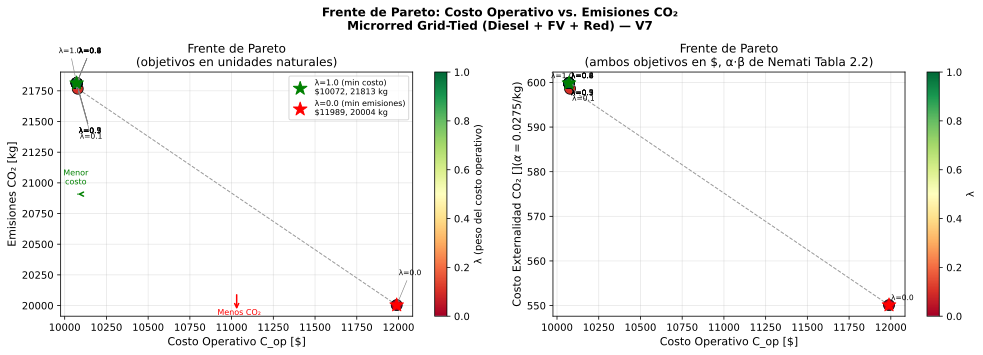

In [112]:
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

c_op_vals  = [r['c_op']     for r in pareto_results]
c_em_vals  = [r['c_em_kg']  for r in pareto_results]
c_em_cost_vals = [r['c_em_cost'] for r in pareto_results]
lam_vals   = [r['lambda']   for r in pareto_results]
ebuy_vals  = [r['e_buy']    for r in pareto_results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Frente de Pareto: Costo Operativo vs. Emisiones CO\u2082\n'
             'Microrred Grid-Tied (Diesel + FV + Red) — V7', fontsize=12, fontweight='bold')

# ── Panel izquierdo: C_op [$] vs CO2 [kg] ───────────────────────────────────
ax1 = axes[0]
cmap = cm.RdYlGn
colors = [cmap(lv) for lv in lam_vals]

ax1.plot(c_op_vals, c_em_vals, 'k--', lw=1, alpha=0.4, zorder=1)
sc = ax1.scatter(c_op_vals, c_em_vals, c=lam_vals, cmap='RdYlGn',
                 s=120, zorder=3, edgecolors='black', linewidths=0.8)

# Anotar lambda en cada punto
for i, (x, y, lv) in enumerate(zip(c_op_vals, c_em_vals, lam_vals)):
    offset_x = 2 if i < len(lam_vals)-1 else -18
    offset_y = 30 if i%2==0 else -50
    ax1.annotate(f'λ={lv:.1f}', (x,y), textcoords='offset points',
                 xytext=(offset_x, offset_y), fontsize=7.5,
                 arrowprops=dict(arrowstyle='->', color='gray', lw=0.6))

# Marcar extremos
ax1.scatter([c_op_vals[-1]], [c_em_vals[-1]], s=200, marker='*',
            color='green', zorder=5, label=f'λ=1.0 (min costo)\n${c_op_vals[-1]:.0f}, {c_em_vals[-1]:.0f} kg')
ax1.scatter([c_op_vals[0]],  [c_em_vals[0]],  s=200, marker='*',
            color='red',   zorder=5, label=f'λ=0.0 (min emisiones)\n${c_op_vals[0]:.0f}, {c_em_vals[0]:.0f} kg')

plt.colorbar(sc, ax=ax1, label='λ (peso del costo operativo)')
ax1.set_xlabel('Costo Operativo C_op [$]', fontsize=11)
ax1.set_ylabel('Emisiones CO\u2082 [kg]', fontsize=11)
ax1.set_title('Frente de Pareto\n(objetivos en unidades naturales)')
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(alpha=0.3)

# Flecha indicando direccion de mejora de cada objetivo
ax1.annotate('', xy=(min(c_op_vals)-5, (max(c_em_vals)+min(c_em_vals))/2),
             xytext=(min(c_op_vals)+20, (max(c_em_vals)+min(c_em_vals))/2),
             arrowprops=dict(arrowstyle='->', color='green', lw=1.5))
ax1.text(min(c_op_vals)-5, (max(c_em_vals)+min(c_em_vals))/2+80,
         'Menor\ncosto', ha='center', fontsize=8, color='green')
ax1.annotate('', xy=((max(c_op_vals)+min(c_op_vals))/2, min(c_em_vals)-50),
             xytext=((max(c_op_vals)+min(c_op_vals))/2, min(c_em_vals)+100),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
ax1.text((max(c_op_vals)+min(c_op_vals))/2+15, min(c_em_vals)-80,
         'Menos CO\u2082', ha='center', fontsize=8, color='red')

# ── Panel derecho: C_op [$] vs C_em_cost [$] (ambos monetizados) ────────────
ax2 = axes[1]
ax2.plot(c_op_vals, c_em_cost_vals, 'k--', lw=1, alpha=0.4, zorder=1)
sc2 = ax2.scatter(c_op_vals, c_em_cost_vals, c=lam_vals, cmap='RdYlGn',
                  s=120, zorder=3, edgecolors='black', linewidths=0.8)

for i, (x, y, lv) in enumerate(zip(c_op_vals, c_em_cost_vals, lam_vals)):
    offset_x = 2 if i < len(lam_vals)-1 else -18
    offset_y = 5 if i%2==0 else -12
    ax2.annotate(f'λ={lv:.1f}', (x,y), textcoords='offset points',
                 xytext=(offset_x, offset_y), fontsize=7.5,
                 arrowprops=dict(arrowstyle='->', color='gray', lw=0.6))

ax2.scatter([c_op_vals[-1]], [c_em_cost_vals[-1]], s=200, marker='*', color='green', zorder=5)
ax2.scatter([c_op_vals[0]],  [c_em_cost_vals[0]],  s=200, marker='*', color='red',   zorder=5)

plt.colorbar(sc2, ax=ax2, label='λ')
ax2.set_xlabel('Costo Operativo C_op [$]', fontsize=11)
ax2.set_ylabel('Costo Externalidad CO\u2082 [$]  (α = 0.0275 $/kg)', fontsize=11)
ax2.set_title('Frente de Pareto\n(ambos objetivos en $, α·β de Nemati Tabla 2.2)')
ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()


## Comparación de Despacho: λ=1.0 vs λ=0.0

Para entender qué cambia en el despacho entre los dos extremos del frente de Pareto.

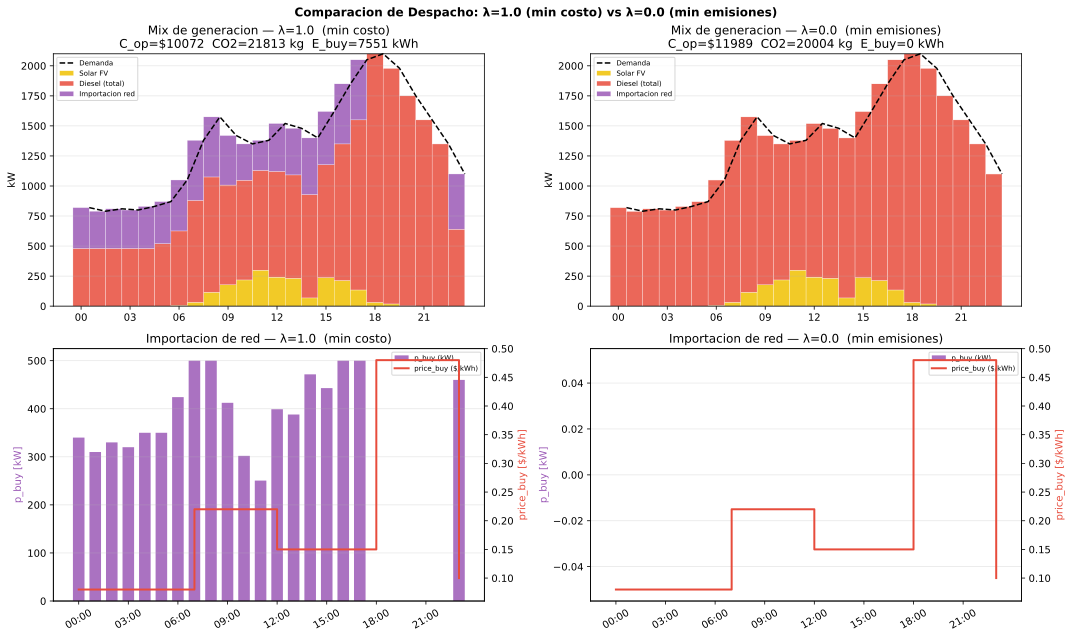

Resumen comparativo extremos del frente de Pareto:
                                   lambda=1.0     lambda=0.0      Delta
----------------------------------------------------------------------
  C_op [$]                          $10071.61      $11989.20    +1917.6
  CO2 total [kg]                     21813 kg       20004 kg    -1809.1
  C_em [$]                            $599.85        $550.10      -49.8
  E_buy [kWh]                      7550.5 kWh        0.0 kWh    -7550.5
  E_diesel [kWh]                  23247.9 kWh    30798.5 kWh    +7550.5


In [113]:
r_cost = pareto_results[-1]   # lambda=1.0: min costo
r_emis = pareto_results[0]    # lambda=0.0: min emisiones

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle('Comparacion de Despacho: λ=1.0 (min costo) vs λ=0.0 (min emisiones)',
             fontsize=12, fontweight='bold')

gen_colors = {'diesel_small':'#3498db','diesel_med':'#e67e22','diesel_large':'#e74c3c'}
hours = list(range(24))
dem_vals = [expected_demand[i] for i in T]
pv_vals  = [pv_output[i] for i in T]

for col, (r, title) in enumerate([(r_cost, 'λ=1.0  (min costo)'),
                                    (r_emis, 'λ=0.0  (min emisiones)')]):
    ax_top = axes[0][col]
    ax_bot = axes[1][col]

    # Mix de generacion
    bottoms = np.zeros(24)
    ax_top.bar(hours, pv_vals, bottom=bottoms, color='#f1c40f', alpha=0.9,
               label='Solar FV', width=1.0, edgecolor='white', lw=0.3)
    bottoms += np.array(pv_vals)
    for g in GENERATORS:
        vals = [r['num_active_vals'][g][i]*max_output[g] for i in T]
        # Usar produccion real si disponible
        vals_out = r['diesel_vals'] if g == GENERATORS[-1] else [0]*24  # placeholder
    # Usar directamente diesel_vals (total) por simplicidad
    ax_top.bar(hours, r['diesel_vals'], bottom=np.array(pv_vals),
               color='#e74c3c', alpha=0.85, label='Diesel (total)', width=1.0,
               edgecolor='white', lw=0.3)
    ax_top.bar(hours, r['pbuy_vals'],
               bottom=np.array(pv_vals)+np.array(r['diesel_vals']),
               color='#9b59b6', alpha=0.85, label='Importacion red',
               width=1.0, edgecolor='white', lw=0.3)
    ax_top.plot([h+0.5 for h in hours], dem_vals, 'k--', lw=1.5, label='Demanda', zorder=5)
    ax_top.set_title(f'Mix de generacion — {title}\n'
                     f'C_op=${r["c_op"]:.0f}  CO2={r["c_em_kg"]:.0f} kg  E_buy={r["e_buy"]:.0f} kWh')
    ax_top.set_ylabel('kW')
    ax_top.set_xticks(range(0,24,3))
    ax_top.set_xticklabels([f'{h:02d}' for h in range(0,24,3)])
    ax_top.legend(fontsize=7, loc='upper left'); ax_top.grid(alpha=0.3, axis='y')

    # Importacion de red por hora
    buy_p = [price_buy[i] for i in T]
    ax_bot.bar(hours, r['pbuy_vals'], color='#9b59b6', alpha=0.85, width=0.7, label='p_buy (kW)')
    ax_bot2 = ax_bot.twinx()
    ax_bot2.step(hours, buy_p, where='post', color='#e74c3c', lw=2, label='price_buy ($/kWh)')
    ax_bot.set_ylabel('p_buy [kW]', color='#9b59b6')
    ax_bot2.set_ylabel('price_buy [$/kWh]', color='#e74c3c')
    ax_bot.set_title(f'Importacion de red — {title}')
    ax_bot.set_xticks(range(0,24,3))
    ax_bot.set_xticklabels([f'{h:02d}:00' for h in range(0,24,3)], rotation=30)
    lines1,lbl1=ax_bot.get_legend_handles_labels()
    lines2,lbl2=ax_bot2.get_legend_handles_labels()
    ax_bot.legend(lines1+lines2, lbl1+lbl2, fontsize=7); ax_bot.grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

print('Resumen comparativo extremos del frente de Pareto:')
print(f'{"":30} {"lambda=1.0":>14} {"lambda=0.0":>14} {"Delta":>10}')
print('-'*70)
for key, label, fmt in [
    ('c_op',     'C_op [$]',          '${:.2f}'),
    ('c_em_kg',  'CO2 total [kg]',     '{:.0f} kg'),
    ('c_em_cost','C_em [$]',           '${:.2f}'),
    ('e_buy',    'E_buy [kWh]',        '{:.1f} kWh'),
    ('e_diesel', 'E_diesel [kWh]',     '{:.1f} kWh'),
]:
    v1 = r_cost[key]; v0 = r_emis[key]
    print(f'  {label:<28} {fmt.format(v1):>14} {fmt.format(v0):>14} {v0-v1:>+10.1f}')


## Análisis del Trade-off en el Frente de Pareto

Visualización de cómo evolucionan las variables clave a lo largo del frente de Pareto.

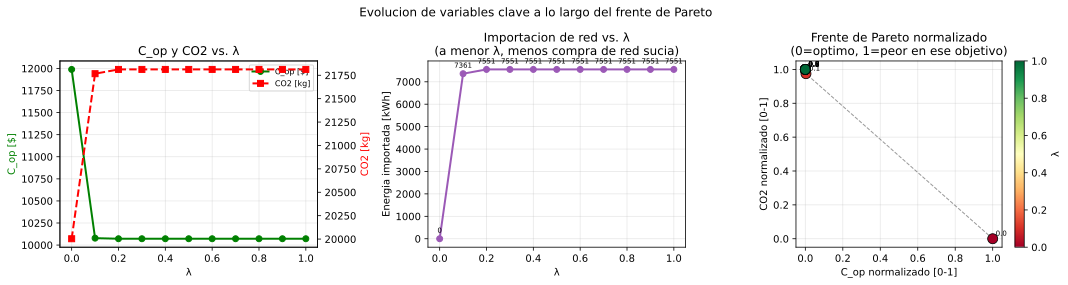

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Evolucion de variables clave a lo largo del frente de Pareto', fontsize=12)

lams = [r['lambda']   for r in pareto_results]
cops  = [r['c_op']    for r in pareto_results]
ems   = [r['c_em_kg'] for r in pareto_results]
ebuys = [r['e_buy']   for r in pareto_results]

# ── C_op y C_em vs lambda ────────────────────────────────────────────────────
ax1 = axes[0]
l1, = ax1.plot(lams, cops, 'go-', ms=6, lw=2, label='C_op [$]')
ax1b = ax1.twinx()
l2, = ax1b.plot(lams, ems, 'rs--', ms=6, lw=2, label='CO2 [kg]')
ax1.set_xlabel('λ'); ax1.set_ylabel('C_op [$]', color='green')
ax1b.set_ylabel('CO2 [kg]', color='red')
ax1.set_title('C_op y CO2 vs. λ')
ax1.legend([l1,l2],[l1.get_label(),l2.get_label()], fontsize=8)
ax1.grid(alpha=0.3)

# ── Importacion de red vs lambda ─────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(lams, ebuys, 'o-', color='#9b59b6', ms=6, lw=2)
ax2.set_xlabel('λ'); ax2.set_ylabel('Energia importada [kWh]')
ax2.set_title('Importacion de red vs. λ\n(a menor λ, menos compra de red sucia)')
ax2.grid(alpha=0.3)
for x,y in zip(lams, ebuys):
    ax2.annotate(f'{y:.0f}', (x,y), textcoords='offset points', xytext=(0,6), fontsize=7, ha='center')

# ── Curva de intercambio Costo-CO2 normalizada (frente de Pareto normalizado) ─
ax3 = axes[2]
c_op_min = min(cops); c_op_max = max(cops)
em_min   = min(ems);  em_max   = max(ems)
cops_n  = [(v-c_op_min)/(c_op_max-c_op_min) if c_op_max>c_op_min else 0 for v in cops]
ems_n   = [(v-em_min)/(em_max-em_min)       if em_max>em_min     else 0 for v in ems]

ax3.plot(cops_n, ems_n, 'k--', lw=1, alpha=0.4)
sc3 = ax3.scatter(cops_n, ems_n, c=lams, cmap='RdYlGn', s=100, zorder=3,
                  edgecolors='black', linewidths=0.8)
for x,y,lv in zip(cops_n, ems_n, lams):
    ax3.annotate(f'{lv:.1f}', (x,y), textcoords='offset points',
                 xytext=(3,3), fontsize=7)
plt.colorbar(sc3, ax=ax3, label='λ')
ax3.set_xlabel('C_op normalizado [0-1]')
ax3.set_ylabel('CO2 normalizado [0-1]')
ax3.set_title('Frente de Pareto normalizado\n(0=optimo, 1=peor en ese objetivo)')
ax3.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## Conclusiones

Este modelo implementa un **análisis biobjetivo Costo–Emisiones CO₂** para una microrred *grid-tied* (diesel + FV + red), generando el frente de Pareto mediante el método de suma escalar ponderada con 11 puntos λ ∈ {0.0, 0.1, …, 1.0}.

**Extensiones respecto a V6:**

1. **Función objetivo de emisiones:** $C^{\mathrm{em}} = \alpha_{\mathrm{CO_2}} [\beta_{\mathrm{DG}} \sum x_{g,t} + \beta_{\mathrm{grid}} \sum p^{\mathrm{buy}}_t]$, usando los factores de Nemati et al. Tabla 2.2. Ambos objetivos están en \$, lo que permite la suma directa sin factor de escala adicional.

2. **Función `build_and_solve(λ)`:** encapsula la construcción y resolución completa del modelo MILP para un λ dado. Cada llamada produce una instancia independiente y retorna los valores de ambos objetivos por separado, sin ponderación.

3. **Frente de Pareto:** los 11 puntos forman el conjunto de soluciones no dominadas. Se visualiza tanto en unidades naturales (\$ vs kg CO₂) como normalizado, al estilo de Nemati Fig. 5.9.

**Trade-off observado:**

El resultado más interesante es que $\beta_{\mathrm{grid}} = 889\,\mathrm{g/kWh} > \beta_{\mathrm{DG}} = 649\,\mathrm{g/kWh}$: la red alemana de 2017 es más sucia que los generadores diesel propios. Por eso:

- Con **λ=1.0** (solo costo): el solver importa energía barata de la red en horas valle → menor costo operativo, pero **mayor** emisión total.
- Con **λ=0.0** (solo emisiones): el solver reduce la importación de red → menor emisión, pero **mayor** costo operativo.

El mecanismo de reducción de emisiones no es encender más diesel (lo cual aumenta las emisiones diesel), sino **reducir la importación de la fuente más contaminante** (la red) y redistribuir la carga entre los generadores propios. La generación FV permanece inalterada en todos los puntos (es no gestionable y siempre preferida por costo cero y emisión cero).

Este resultado ilustra la importancia de conocer el mix eléctrico de la red de servicio antes de tomar decisiones de operación basadas en criterios ambientales. Un mix con alta participación de renovables (como Argentina en momentos de alto caudal hidráulico) produciría el trade-off inverso.